In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

1. Data Ingestion

In [2]:
import requests
import zipfile
import io

# The direct download URL for the dataset
url = "https://analyse.kmi.open.ac.uk/open-dataset/download"

print("Downloading dataset...")
response = requests.get(url)

# Unzip the content into a folder named 'oulad_data'
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("FAIDM/oulad_data")
    print("Files extracted: ", z.namelist())

Files extracted:  ['studentAssessment.csv', 'studentVle.csv', 'assessments.csv', 'courses.csv', 'studentInfo.csv', 'studentRegistration.csv', 'vle.csv']


2. Data Loading

In [3]:
dir = 'FAIDM/oulad_data/'

studentInfo = pd.read_csv(dir + 'studentInfo.csv')
courses = pd.read_csv(dir + 'courses.csv')
assessments = pd.read_csv(dir + 'assessments.csv')
studentRegistration = pd.read_csv(dir + 'studentRegistration.csv')
studentAssessment = pd.read_csv(dir + 'studentAssessment.csv')
studentVle = pd.read_csv(dir + 'studentVle.csv')
vle = pd.read_csv(dir + 'vle.csv')

- Adding Course Registration Status and Module Length in studentInfo

In [4]:
studentCourseRegistration = pd.merge(studentRegistration, courses, on=['code_module', 'code_presentation'], how='left')
students = pd.merge(studentInfo, studentCourseRegistration, on=['id_student', 'code_module', 'code_presentation'], how='left')

- Students Demographics

In [5]:
def clean_student_demographics(df):
  # IMD_BAND
  imd_mapping = {
      '0-10%': 5, '10-20%': 15, '20-30%': 25, '30-40%': 35, '40-50%': 45,
      '50-60%': 55, '60-70%': 65, '70-80%': 75, '80-90%': 85, '90-100%': 95
  }
  df['imd_band_clean'] = df['imd_band'].map(imd_mapping)
  df['imd_band_clean'] = df['imd_band_clean'].fillna(-1) # filling -1 as imd_band for unknown

  # AGE BAND
  age_midpoint_map = { '0-35': 18, '35-55': 45, '55<=': 60 }
  df['age_band_clean'] = df['age_band'].map(age_midpoint_map)

  # EDUCATION
  edu_standard_map = {
      'Post Graduate Qualification': 'Post_Grad',
      'HE Qualification': 'Higher_Ed',
      'A Level or Equivalent': 'A_Level',
      'Lower Than A Level': 'Below_A_Level',
      'No Formal quals': 'No_Formal'
  }
  df['edu_clean'] = df['highest_education'].map(edu_standard_map)

  # REGION MAP - Prevents Overfitting
  region_map = {
      'Scotland': 'North', 'North Western Region': 'North', 'Yorkshire Region': 'North', 'North Region': 'North',
      'South Region': 'South', 'South West Region': 'South', 'South East Region': 'South',
      'East Anglian Region': 'Midlands_East', 'West Midlands Region': 'Midlands_East', 'East Midlands Region': 'Midlands_East',
      'London Region': 'London',
      'Wales': 'Devolved_Ireland', 'Ireland': 'Devolved_Ireland'
  }
  df['region_clean'] = df['region'].map(region_map)
  return df

students = clean_student_demographics(students)

# ONE HOT ENCODING FOR STUDENTS
cols_to_encode = ['gender', 'disability']
df_students = pd.get_dummies(students, columns=cols_to_encode, drop_first=True, dtype=int)
cols_to_encode = ['edu_clean', 'region_clean']
df_students = pd.get_dummies(df_students, columns=cols_to_encode, dtype=int)

cols_to_drop = ['highest_education', 'region', 'imd_band', 'age_band']
df_students = df_students.drop(columns=[c for c in cols_to_drop if c in df_students.columns])
df_students.head()

,code_module,code_presentation,id_student,num_of_prev_attempts,studied_credits,final_result,date_registration,date_unregistration,module_presentation_length,imd_band_clean,age_band_clean,gender_M,disability_Y,edu_clean_A_Level,edu_clean_Below_A_Level,edu_clean_Higher_Ed,edu_clean_No_Formal,edu_clean_Post_Grad,region_clean_Devolved_Ireland,region_clean_London,region_clean_Midlands_East,region_clean_North,region_clean_South
0,AAA,2013J,11391,0,240,Pass,-159.0,NaN,268,95.0,60,1,0,0,0,1,0,0,0,0,1,0,0
1,AAA,2013J,28400,0,60,Pass,-53.0,NaN,268,25.0,45,0,0,0,0,1,0,0,0,0,0,1,0
2,AAA,2013J,30268,0,60,Withdrawn,-92.0,12.0,268,35.0,45,0,1,1,0,0,0,0,0,0,0,1,0
3,AAA,2013J,31604,0,60,Pass,-52.0,NaN,268,55.0,45,0,0,1,0,0,0,0,0,0,0,0,1
4,AAA,2013J,32885,0,60,Pass,-176.0,NaN,268,55.0,18,0,0,0,1,0,0,0,0,0,1,0,0


- Modules Academic Metadata

In [6]:
# IMPORTANT ------ # Removing all the exam scores from the data

assessments = assessments[assessments['assessment_type'] != 'Exam']

# INPORTANT ------ # Removing all student assessement records where data_submission < 0 and is_banked == 0

studentAssessment = studentAssessment[~((studentAssessment['date_submitted'] < 0) & (studentAssessment['is_banked'] == 0))]


In [7]:
def map_assessment_weights(group):
    type_weights = group.groupby('assessment_type')['weight'].agg(['sum', 'size'])
    return ', '.join([
        f"{t} ({int(row['size'])} , {row['sum']}% )"
        for t, row in type_weights.sort_index().iterrows()
    ])

df_modules =  assessments.groupby(['code_module', 'code_presentation']).apply(
    lambda x: pd.Series({
        'total_weight': x['weight'].sum(),
        'assessment_count': x['weight'].count(),
        'optional_count': (x['weight'] == 0).sum(),
        'core_count': (x['weight'] != 0).sum(),
        'exam_count': (x['assessment_type'] == 'Exam').sum(),
        'exam_weight': x[x['assessment_type'] == 'Exam']['weight'].sum(),
        # 'weight_by_type': map_assessment_weights(x)
    })
).reset_index()
df_modules

,code_module,code_presentation,total_weight,assessment_count,optional_count,core_count,exam_count,exam_weight
0,AAA,2013J,100.0,5.0,0.0,5.0,0.0,0.0
1,AAA,2014J,100.0,5.0,0.0,5.0,0.0,0.0
2,BBB,2013B,100.0,11.0,0.0,11.0,0.0,0.0
3,BBB,2013J,100.0,11.0,0.0,11.0,0.0,0.0
4,BBB,2014B,100.0,11.0,0.0,11.0,0.0,0.0
5,BBB,2014J,100.0,5.0,1.0,4.0,0.0,0.0
6,CCC,2014B,100.0,8.0,0.0,8.0,0.0,0.0
7,CCC,2014J,100.0,8.0,0.0,8.0,0.0,0.0
8,DDD,2013B,100.0,13.0,0.0,13.0,0.0,0.0
9,DDD,2013J,100.0,6.0,0.0,6.0,0.0,0.0


- Student Academic Performance

In [8]:
# STUDENT PERFORMANCE
df_student_performance = pd.merge(studentAssessment, assessments, on=['id_assessment'])
df_student_performance['core_score'] = df_student_performance['score'] * df_student_performance['weight'] * 0.01
df_student_performance['optional_score'] = df_student_performance['score'].where(df_student_performance['weight'] == 0, 0)
df_student_performance['exam_score'] = np.where(
    df_student_performance['assessment_type'] == 'Exam',
    df_student_performance['score'] * df_student_performance['weight'] * 0.01,
    0
)
df_student_performance['submission_gap'] = df_student_performance['date_submitted'] - df_student_performance['date']

df_student_performance = df_student_performance.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    attempted_core_score = ('core_score', 'sum'),
    attempted_core_weight = ('weight', 'sum'),
    attempted_core = ('weight', lambda x: (x > 0).sum()),
    attempted_optional_score = ('optional_score', 'sum'),
    attempted_optional = ('optional_score', lambda x: (x != 0).sum()),
    avg_submission_gap = ('submission_gap', 'mean'),
    # std_submission_gap = ('submission_gap', 'std'),
    has_banked_score = ('is_banked', 'max'),
    is_final_exam_score_avlbl = ('assessment_type', lambda x: (x == 'Exam').sum()),
    exam_score = ('exam_score', 'sum'),
).reset_index()

df_student_performance['is_early_submitter'] = (df_student_performance['avg_submission_gap'] < -5).astype(int)


df_student_performance = pd.merge(df_student_performance, df_modules, on=['code_module', 'code_presentation'])
# df_student_performance[df_student_performance['attempted_optional'] > 0].head()
df_student_performance['performance_efficiency'] = (
    df_student_performance['attempted_core_score'] / (df_student_performance['attempted_core_weight'] * 0.01 + 1e-5)
)

df_student_performance['core_completion_ratio'] = df_student_performance['attempted_core'] / (df_student_performance['core_count']* 0.01 + 1e-5)
df_student_performance['optional_completion_ratio'] = df_student_performance['attempted_optional'] / (df_student_performance['optional_count'] + 1e-5)

df_student_performance['total_attempt_ratio'] = (
    (df_student_performance['attempted_core'] + df_student_performance['attempted_optional']) /
    df_student_performance['assessment_count']
)

df_student_performance['attempted_optional_score'] = df_student_performance['attempted_optional_score'] / (df_student_performance['optional_count'] + 1e-5)


# df_student_performance['avg_submission_gap'] = df_student_performance['avg_submission_gap'].clip(-50, 50)

# Final column selection for the ML ready table
df_student_performance = df_student_performance[[
    'id_student', 'code_module', 'code_presentation',
    'performance_efficiency', 'total_attempt_ratio',
    'attempted_core_score', 'core_completion_ratio',
    'attempted_optional_score', 'optional_completion_ratio',
    'avg_submission_gap', 'is_early_submitter',
    'exam_score', 'has_banked_score', 'is_final_exam_score_avlbl'
]]


In [9]:
df_student_performance[df_student_performance['core_completion_ratio'].isnull()]

,id_student,code_module,code_presentation,performance_efficiency,total_attempt_ratio,attempted_core_score,core_completion_ratio,attempted_optional_score,optional_completion_ratio,avg_submission_gap,is_early_submitter,exam_score,has_banked_score,is_final_exam_score_avlbl


- Student Engagement

In [10]:
activity_map = {
    'forumng': 'Social', 'ouwiki': 'Social', 'oucollaborate': 'Social',
    'quiz': 'Active_Study', 'externalquiz': 'Active_Study', 'questionnaire': 'Active_Study',
    'oucontent': 'Content', 'resource': 'Content', 'url': 'Content', 'page': 'Content', 'folder': 'Content',
    'homepage': 'Nav', 'subpage': 'Nav', 'ouelluminate': 'Nav'
}
vle_with_cat = vle.copy()
vle_with_cat['activity_category'] = vle['activity_type'].map(activity_map)

cols_to_drop = ['activity_type', 'week_from', 'week_to']
vle_with_cat = vle_with_cat.drop(columns=[c for c in cols_to_drop if c in vle_with_cat.columns])
vle_with_cat.head()

,id_site,code_module,code_presentation,activity_category
0,546943,AAA,2013J,Content
1,546712,AAA,2013J,Content
2,546998,AAA,2013J,Content
3,546888,AAA,2013J,Content
4,547035,AAA,2013J,Content


In [11]:
df_student_vle = studentVle.groupby(["id_student", "code_module", "code_presentation", "id_site", "date"]).agg(
    sum_click=("sum_click", "sum")
).reset_index()

df_student_vle["early_access"] = (df_student_vle["date"] < 0).astype(int)
df_student_vle["week"] = (df_student_vle["date"] // 7).astype(int)
df_student_vle.head()

,id_student,code_module,code_presentation,id_site,date,sum_click,early_access,week
0,6516,AAA,2014J,877011,204,6,0,29
1,6516,AAA,2014J,877011,209,8,0,29
2,6516,AAA,2014J,877011,218,9,0,31
3,6516,AAA,2014J,877012,0,38,0,0
4,6516,AAA,2014J,877012,5,12,0,0


In [12]:

df_engagement = pd.merge(df_student_vle, vle_with_cat, on=['id_site', 'code_module', 'code_presentation'], how='inner')

df_engagement_agg = df_engagement.groupby(["id_student", "code_module", "code_presentation"]).agg(
    total_clicks=("sum_click", "sum"),
    active_days=("date", "nunique"),
    active_weeks=("week", "nunique"),
    has_early_access=("early_access", "max")
).reset_index()


df_engagement_agg_by_category = df_engagement.groupby(['id_student', 'code_module', 'code_presentation', 'activity_category']).agg(
    click = ('sum_click', 'sum'),
    active_days=('date', 'nunique'),
).unstack(fill_value=0)

df_engagement_agg_by_category.columns = [f'{metric}{"_" if cat else ""}{cat}' for metric, cat in df_engagement_agg_by_category.columns]
df_engagement_agg_by_category = df_engagement_agg_by_category.reset_index()


df_student_engagement = pd.merge(df_engagement_agg, df_engagement_agg_by_category, on=['id_student', 'code_module', 'code_presentation'], how='left')


- Merging all the tables in one

In [13]:
print(df_students.shape)
print(df_student_performance.shape)
print(df_student_engagement.shape)


(32593, 23)
(25832, 14)
(29228, 15)


In [14]:
df_performance_engagement = pd.merge( df_student_performance, df_student_engagement, on=['id_student', 'code_module', 'code_presentation'], how='outer')

df_student_performance_engagement = pd.merge(df_students, df_performance_engagement, on=['id_student', 'code_module', 'code_presentation'], how='inner')

df_student_performance_engagement.shape



(29277, 46)

In [15]:
# TAKING STUDENTS WITH EITHER PERFORMANCE DATA OR VLE DATA AVAILABLE
df_final = df_student_performance_engagement[
    (~df_student_performance_engagement['exam_score'].isnull()) &
    (~df_student_performance_engagement['total_clicks'].isnull())
  ]

cols_to_encode = ['code_module']
df_final = pd.get_dummies(df_final, columns=cols_to_encode, dtype=int)
df_final = df_final[[
       'code_module_AAA', 'code_module_BBB','code_module_CCC', 'code_module_DDD', 'code_module_EEE', 'code_module_FFF', 'code_module_GGG',
       'num_of_prev_attempts',
       'studied_credits',
       'imd_band_clean',
       'age_band_clean',
       'edu_clean_A_Level', 'edu_clean_Below_A_Level', 'edu_clean_Higher_Ed', 'edu_clean_No_Formal', 'edu_clean_Post_Grad',
       'region_clean_Devolved_Ireland','region_clean_London', 'region_clean_Midlands_East', 'region_clean_North', 'region_clean_South',
       'gender_M',
       'disability_Y',
       'total_attempt_ratio','performance_efficiency',
       'attempted_core_score', 'core_completion_ratio',
       'attempted_optional_score', 'optional_completion_ratio',
       'has_banked_score',
       'avg_submission_gap', 'is_early_submitter',
       'total_clicks', 'active_days', 'active_weeks', 'has_early_access',
       'click_Active_Study', 'click_Content', 'click_Nav', 'click_Social',
       'active_days_Active_Study', 'active_days_Content', 'active_days_Nav', 'active_days_Social',
       'final_result']]
df_final.shape


(25783, 45)

- Standarized Columns

In [16]:
from sklearn.preprocessing import StandardScaler

# 1. List only the continuous numerical columns
cols_to_scale = [
    'studied_credits',
    'total_clicks',
    'active_days',
    'active_weeks',
    'click_Active_Study', 'click_Content', 'click_Nav', 'click_Social',
    'active_days_Active_Study', 'active_days_Content', 'active_days_Nav', 'active_days_Social',
    'avg_submission_gap'
]

scaler = StandardScaler()

df_final_scaled = df_final.copy()
df_final_scaled[cols_to_scale] = scaler.fit_transform(df_final[cols_to_scale])

df_final_scaled.describe()

,code_module_AAA,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,num_of_prev_attempts,studied_credits,imd_band_clean,age_band_clean,edu_clean_A_Level,edu_clean_Below_A_Level,edu_clean_Higher_Ed,edu_clean_No_Formal,edu_clean_Post_Grad,region_clean_Devolved_Ireland,region_clean_London,region_clean_Midlands_East,region_clean_North,region_clean_South,gender_M,disability_Y,total_attempt_ratio,performance_efficiency,attempted_core_score,core_completion_ratio,attempted_optional_score,optional_completion_ratio,has_banked_score,avg_submission_gap,is_early_submitter,total_clicks,active_days,active_weeks,has_early_access,click_Active_Study,click_Content,click_Nav,click_Social,active_days_Active_Study,active_days_Content,active_days_Nav,active_days_Social
count,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,2.578300e+04,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,25783.000000,2.578300e+04,25783.000000,2.578300e+04,2.578300e+04,2.578300e+04,25783.000000,2.578300e+04,2.578300e+04,2.578300e+04,2.578300e+04,25783.000000,2.578300e+04,2.578300e+04,2.578300e+04
mean,0.027344,0.234612,0.132258,0.191095,0.089051,0.243843,0.081798,0.154986,4.409372e-17,44.877594,26.356553,0.444983,0.380794,0.154482,0.008921,0.010821,0.107629,0.093783,0.249699,0.310127,0.238762,0.550246,0.093434,0.753351,64.137929,48.640875,70.098514,22.416096,0.297773,0.019082,7.936870e-17,0.282900,1.763749e-17,9.700618e-17,-1.146437e-16,0.826863,3.527498e-17,-3.747966e-17,6.614058e-17,-3.086560e-17,0.000000,7.054995e-17,1.146437e-16,-2.645623e-17
std,0.163086,0.423764,0.338777,0.393171,0.284823,0.429407,0.274062,0.465499,1.000019e+00,31.247825,12.663746,0.496974,0.485591,0.361417,0.094029,0.103462,0.309917,0.291532,0.432847,0.462554,0.426335,0.497479,0.291045,0.324956,25.753849,31.962910,36.536142,36.129616,0.442434,0.136817,1.000019e+00,0.450417,1.000019e+00,1.000019e+00,1.000019e+00,0.378373,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019,1.000019e+00,1.000019e+00,1.000019e+00
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.221738e+00,-1.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-8.542823e+00,0.000000,-8.559602e-01,-1.284665e+00,-2.044457e+00,0.000000,-5.598763e-01,-6.962934e-01,-8.622245e-01,-5.272062e-01,-0.887462,-1.151691e+00,-1.289255e+00,-8.158254e-01
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.380858e-01,25.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,55.972014,15.835000,39.992002,0.000000,0.000000,0.000000,5.098590e-02,0.000000,-6.361193e-01,-7.959074e-01,-8.827373e-01,1.000000,-5.313028e-01,-5.928647e-01,-6.070381e-01,-4.707982e-01,-0.625729,-7.455649e-01,-7.895046e-01,-6.681507e-01
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.380858e-01,45.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,70.997633,56.000000,90.900827,0.000000,0.000000,0.000000,4.292658e-01,0.000000,-3.459968e-01,-2.507542e-01,1.002566e-01,1.000000,-3.761895e-01,-3.846094e-01,-3.172501e-01,-3.046230e-01,-0.276751,-2.852892e-01,-2.513123e-01,-3.728011e-01
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.455661e-01,75.000000,45.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,81.991801,77.250000,99.980004,58.111047,0.999990,0.000000,5.054296e-01,1.000000,2.632042e

In [17]:
df_final_scaled.to_csv('FAIDM/final_scaled.csv', index=False)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# The df_final_scaled DataFrame was prepared in previous steps and is available in memory.
# We will use it directly instead of loading a new file.
df_dbscan = df_final_scaled.copy()

# We select 'performance_efficiency' (grades) and 'total_clicks' (engagement)
# These are the best for identifying student behavior patterns
features = ['performance_efficiency', 'total_clicks']
X_dbscan = df_dbscan[features]

print(f"Features selected for DBSCAN: {features}")

Features selected for DBSCAN: ['performance_efficiency', 'total_clicks']


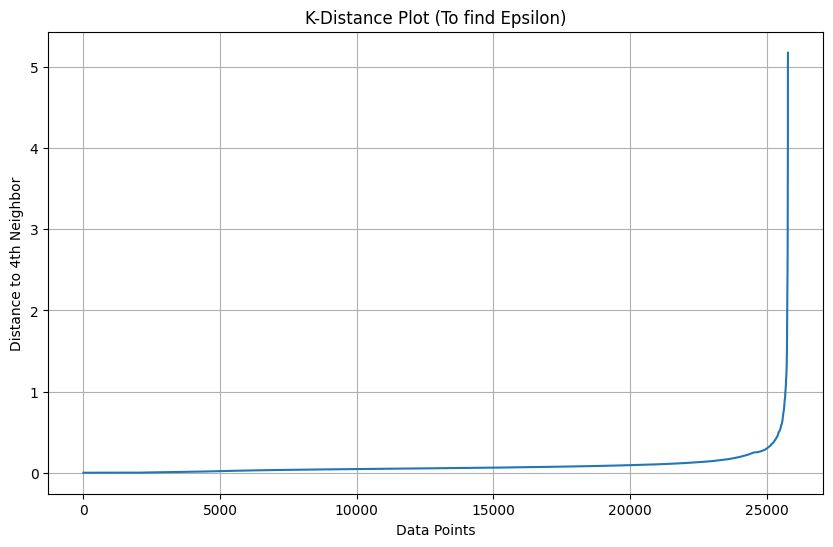

In [19]:
# We use 4 neighbors because MinPts is usually 2 * dimensions
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_dbscan)
distances, indices = neighbors_fit.kneighbors(X_dbscan)

# Sort the distances and plot
distances = np.sort(distances[:, 3], axis=0)
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-Distance Plot (To find Epsilon)')
plt.xlabel('Data Points')
plt.ylabel('Distance to 4th Neighbor')
plt.grid(True)
plt.show()

In [20]:
# Set parameters based on the Elbow Plot
# eps: the distance we found (0.2 is a good starting point for OULAD)
# min_samples: minimum points to be a 'cluster'
eps_val = 0.2
min_samples_val = 10

dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
df_dbscan['dbscan_cluster'] = dbscan.fit_predict(X_dbscan)

# See how many clusters were found
print("Cluster counts (-1 indicates Noise/Outliers):")
print(df_dbscan['dbscan_cluster'].value_counts())

Cluster counts (-1 indicates Noise/Outliers):
dbscan_cluster
 0     19209
-1      3048
 4      2388
 2       161
 20       60
 14       49
 13       48
 17       42
 18       39
 3        31
 10       31
 25       30
 1        26
 37       24
 12       24
 36       23
 33       23
 27       23
 24       21
 45       21
 31       20
 28       20
 5        19
 19       19
 30       18
 11       17
 21       17
 40       16
 41       15
 29       14
 9        14
 50       13
 49       13
 35       12
 23       12
 44       12
 6        12
 16       11
 32       11
 46       11
 38       10
 48       10
 53       10
 54       10
 43       10
 52       10
 7        10
 39       10
 47       10
 42        9
 22        9
 8         9
 15        8
 51        7
 55        7
 34        6
 57        6
 26        5
 56        5
 58        5
Name: count, dtype: int64


C:\Users\john2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\john2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\john2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) 

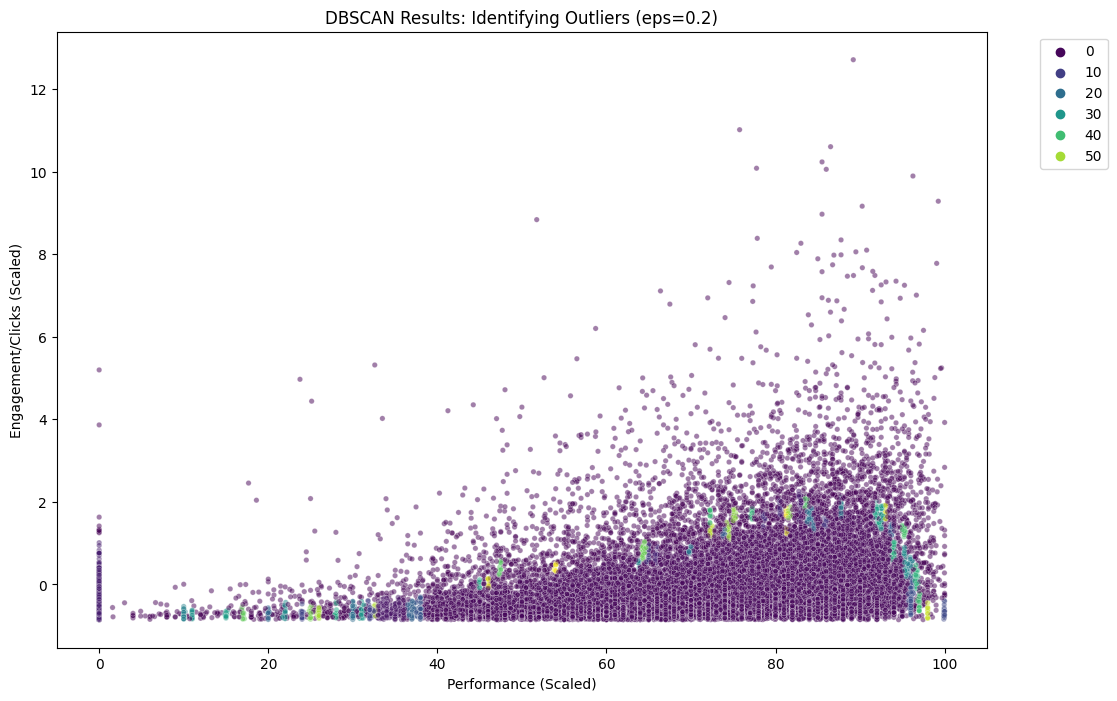

In [21]:
plt.figure(figsize=(12, 8))
# We use a scatter plot to show the density-based groups
sns.scatterplot(x='performance_efficiency', y='total_clicks',
                hue='dbscan_cluster', data=df_dbscan,
                palette='viridis', alpha=0.5, s=15)

plt.title(f'DBSCAN Results: Identifying Outliers (eps={eps_val})')
plt.xlabel('Performance (Scaled)')
plt.ylabel('Engagement/Clicks (Scaled)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [22]:
# Check the composition of your Noise group (-1)
noise_analysis = df_dbscan[df_dbscan['dbscan_cluster'] == -1]['final_result'].value_counts(normalize=True) * 100
print("Composition of 'Noise' (At-Risk) Group:")
print(noise_analysis.round(2))

Composition of 'Noise' (At-Risk) Group:
final_result
Pass           52.03
Distinction    22.34
Fail           15.91
Withdrawn       9.71
Name: proportion, dtype: float64


In [23]:
# Select the key engagement and performance metrics
profile_cols = ['total_clicks', 'active_days', 'performance_efficiency', 'dbscan_cluster']

# Calculate the average for each cluster
cluster_profiles = df_dbscan[profile_cols].groupby('dbscan_cluster').mean()
print("Average Metrics per Cluster (High numbers mean more engagement/success):")
cluster_profiles

Average Metrics per Cluster (High numbers mean more engagement/success):


,total_clicks,active_days,performance_efficiency
dbscan_cluster,,,
-1,1.747111,1.296597,69.159944
0,-0.215716,-0.126548,71.776733
1,-0.652771,-0.782170,36.057856
2,-0.652446,-0.818325,34.119642
3,1.920571,1.472027,82.865890
4,-0.544193,-0.641569,0.000000
5,0.686862,0.806902,65.867849
6,1.818677,1.315778,80.497398
7,1.594282,1.630964,78.593978


In [24]:
# Check if certain groups are more likely to be in the 'At-Risk' Noise group
demographic_cols = ['disability_Y', 'gender_M', 'dbscan_cluster']
demo_analysis = df_dbscan[demographic_cols].groupby('dbscan_cluster').mean() * 100

print("Demographic Percentages per Cluster:")
print("(e.g., if disability_Y is high in Cluster -1, they need special support)")
demo_analysis.round(2)

Demographic Percentages per Cluster:
(e.g., if disability_Y is high in Cluster -1, they need special support)


,disability_Y,gender_M
dbscan_cluster,,
-1,9.28,67.81
0,8.78,56.47
1,3.85,46.15
2,13.04,63.98
3,3.23,64.52
4,13.23,20.48
5,15.79,63.16
6,8.33,66.67
7,10.00,70.00


Experimental

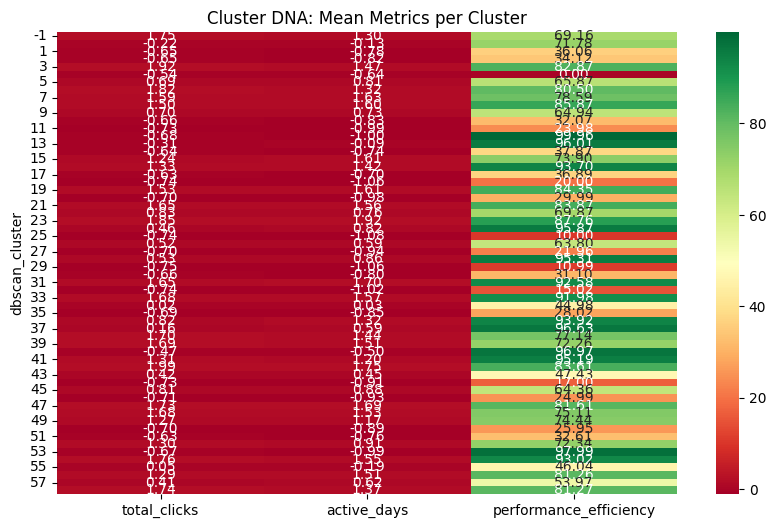

In [25]:
import plotly.express as px

# 1. 3D Interactive Cluster Map
# Adds a 3rd dimension (active_days) to see the density in 3D space.
fig = px.scatter_3d(df_dbscan,
                    x='performance_efficiency', y='total_clicks', z='active_days',
                    color='dbscan_cluster',
                    title='3D Interactive Student Cluster Map (DBSCAN)')
fig.show()

# 2. Cluster DNA Heatmap
# Shows exactly what makes each student cluster unique.
profile_cols_all = ['total_clicks', 'active_days', 'performance_efficiency']
cluster_dna = df_dbscan.groupby('dbscan_cluster')[profile_cols_all].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_dna, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Cluster DNA: Mean Metrics per Cluster')
plt.show()